<a href="https://colab.research.google.com/github/bhuvanarangaiah/03MAIR-Algoritmos-de-Optimizacion-2026/blob/main/AG/BhuvanaRangaiahCheemalaMarri_Algoritmos_Genetico_para_el_TSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos - Actividad Guiada 3 Genetico para el TSP

Nombre: Bhuvana Rangaiah Cheemala Marri<br>
Colab URL: https://colab.research.google.com/github/bhuvanarangaiah/03MAIR-Algoritmos-de-Optimizacion-2026/blob/main/AG/BhuvanaRangaiahCheemalaMarri_Algoritmos_Genetico_para_el_TSP.ipynb

Github URL: https://github.com/bhuvanarangaiah/03MAIR-Algoritmos-de-Optimizacion-2026/blob/main/AG/BhuvanaRangaiahCheemalaMarri_Algoritmos_Genetico_para_el_TSP.ipynb


# Instalación de librerias

In [16]:
!pip install requests
import urllib.request

!pip install tsplib95
import tsplib95

In [17]:
import random   #Libreria para generar numeros y listas aleatorias
import copy     #Permite hacer copias de objetos en python: listas, diccionarios,...

# Carga de datos del problema

In [18]:
#Librerias y carga del problema

#http://elib.zib.de/pub/mp-testdata/tsp/tsplib/
#Documentacion :
  # https://wwwproxy.iwr.uni-heidelberg.de/groups/comopt/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/usage.html
  # https://tsplib95.readthedocs.io/modules.html#module-tsplib95.models

#Matriz de distancias
file = "swiss42.tsp" ;
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )    #Descomprimir el fichero de datos

#Objeto de tsplib95 para nuestro problema problema
problema = tsplib95.load(file)

#Nodos
nodos = list(problema.get_nodes())

#Aristas
Aristas = list(problema.get_edges())
print(Aristas)

#Coordenadas(si estan disponibles en el ficher)
problema.get_display(1)

#Distancia
problema.get_weight(1, 2)



[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 28), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0, 36), (0, 37), (0, 38), (0, 39), (0, 40), (0, 41), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 24), (1, 25), (1, 26), (1, 27), (1, 28), (1, 29), (1, 30), (1, 31), (1, 32), (1, 33), (1, 34), (1, 35), (1, 36), (1, 37), (1, 38), (1, 39), (1, 40), (1, 41), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16), (2, 17), (2, 18), (2, 19), (2, 20), (2, 21), (2, 22), (2, 23), (2, 24), (2, 25), (2, 26), (2, 27), (2, 28), (2, 29), (2,

34

In [33]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, metric="precomputed", random_state=42, init="classical_mds")
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()

# Funciones de la Actividad Guiada 3

In [34]:
# Genera una solución aleatoria con comienzo en en el nodo 0
def crear_solucion(nodos):
    # Nodo inicial = 0
    solucion = [nodos[0]]
    # Para el resto de nodos, los recorremos e incluimos aleatoriamente en la solución cada uno de ellos
    for n in nodos[1:]:
        # Debemos quitar el nodo 0 y los ya incluidos en cada iteración
        solucion = solucion + [random.choice(list(set(nodos) - set({nodos[0]}) - set(solucion)))]
    return solucion


# Devuelve la distancia entre dos nodos aprovechando la función get_weight() de tsplib95
def distancia(a,b, problema):
    return problema.get_weight(a,b)


# Devuelve la distancia total de una trayectoria/solución
def distancia_total(solucion, problema):
    distancia_total = 0
    # Para cada nodo de la solución calculamos su distancia a siguiente nodo
    for i in range(len(solucion)-1):
        distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problema)
    # Devolvemos la distancia total más la distancia del último nodo al primero para cerrar viaje
    return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problema)


solucion = crear_solucion(nodos)
print(solucion)
print(distancia_total(solucion, problema))

[0, 30, 5, 1, 35, 24, 23, 9, 12, 6, 26, 37, 7, 25, 3, 38, 39, 22, 28, 20, 40, 31, 34, 33, 19, 11, 21, 27, 4, 17, 13, 18, 8, 2, 15, 32, 16, 36, 14, 41, 10, 29]
4129


# Funciones Auxiliares

In [35]:
# Genera una población inicial de soluciones de tamaño tamano_poblacion.
# Puede ser válida la solución aleatoria de la AG3: crear_solucion(nodos)
def generar_poblacion(nodos,tamano_poblacion):
    return [crear_solucion(nodos) for _ in range(tamano_poblacion)]

In [36]:
# Evalúa la población y devuelve el mejor individuo
def evaluar_poblacion(poblacion, problema):
    mejor_solucion = []
    mejor_distancia = float("inf")

    for p in poblacion:
        distancia_referencia = distancia_total(p, problema)
        if (distancia_referencia < mejor_distancia):
            mejor_solucion = p
            mejor_distancia = distancia_referencia

    return mejor_solucion, mejor_distancia

In [37]:
# Función de cruce. Recibe una población (lista de soluciones) y devuelve la población ampliada con los hijos.
# Todos los individuos de la población son selecionados para el cruce (si la población es par)
# Podría aplicarse un proceso previo de selección para elegir los individuos que se desea cruzar.
def cruzar(poblacion, mutacion, problema):
    poblacion_copia = copy.deepcopy(poblacion)
    poblacion_final = copy.deepcopy(poblacion)

    while(len(poblacion_copia) > 1):
        padre1, padre2 = random.sample(poblacion_copia, 2)
        poblacion_copia.remove(padre1)
        poblacion_copia.remove(padre2)
        poblacion_final.extend(descendencia([padre1, padre2], problema, mutacion))

    return poblacion_final

In [38]:
# Función para generar hijos a partir de 2 padres:
# Se elige el metodo de 1-punto de corte pero es posible usar otros n-puntos, uniforme, dependiendo del problema
def descendencia(padres, problema, mutacion):
    punto_corte = random.sample(range(1, len(padres[0])), 1)[0]

    hijo1 = padres[0][:punto_corte] + padres[1][punto_corte:]
    hijo2 = padres[1][:punto_corte] + padres[0][punto_corte:]

    hijo1 = factibilizar(hijo1, problema)
    hijo2 = factibilizar(hijo2, problema)

    mutacion1 = mutar(hijo1, mutacion)
    mutacion2 = mutar(hijo2, mutacion)

    mutacion1 = factibilizar(mutacion1, problema)
    mutacion2 = factibilizar(mutacion2, problema)


    return [hijo1, hijo2, mutacion1, mutacion1]

In [39]:
# Para el operador de cruce 1-punto los hijos generados no son soluciones (algunos nodos se repiten y otros no están)
def factibilizar(solucion, problema):
    solucion = solucion[:]

    nodos = list(problema.get_nodes())
    nodos_desaparecidos = list(set(nodos) - set(solucion))

    usados = {}

    for i in range(len(solucion)):
        if solucion[i] in usados:
            solucion[i] = nodos_desaparecidos.pop(0)
        else:
            usados[solucion[i]] = True

    return solucion

In [40]:
# Función de mutación. Se eligen dos nodos y se intercambia. Se podrían añadir otros operaradores
# Se hace mutaciones mutacion% de las veces
def mutar(solucion, mutacion):
    if random.random() < mutacion:
        i, j = random.sample(range(len(solucion)), 2)

        solucion = solucion[:]
        solucion[i], solucion[j] = solucion[j], solucion[i]

        return solucion

    return solucion[:]

In [41]:
# Función de selección de la población. Recibe como parámetro una población y
# devuelve una población a la que se ha eliminado individuos poco aptos (fitness alto) y para mantener una población estable de tamano_poblacion individuos
# Se tiene en cuenta el porcentaje elitismo pasado como parámetro
# Para los individuos que no son de la élite podríamos usar una selección de ruleta (proporcional a su fitness)
def seleccionar(problema, poblacion, tamano_poblacion, elitismo):
    # Se ordena la población según el fitness (tamaño del recorrido) en una lista de elementos [distancia, solucion]
    poblacion_ordenada = sorted([ [distancia_total(solucion,problema), solucion] for solucion in poblacion ], key = lambda x:x[0])

    # Devolvemos elitismo% y el resto se eligen aleatoriamente
    return [x[1] for x in poblacion_ordenada][:int(tamano_poblacion*elitismo)] + random.sample([x[1] for x in poblacion_ordenada][int(tamano_poblacion*elitismo):] , int(tamano_poblacion*(1-elitismo)) )

#Proceso Principal

Generacion # 0 
La mejor solución es: [0, 37, 28, 24, 34, 22, 3, 31, 15, 11, 2, 4, 26, 19, 14, 41, 12, 23, 29, 25, 5, 7, 32, 30, 38, 33, 20, 39, 21, 40, 9, 8, 13, 10, 35, 36, 1, 18, 16, 6, 17, 27] 
con distancia  3581 

Generacion # 1 
La mejor solución es: [0, 37, 28, 24, 34, 22, 3, 31, 15, 11, 2, 4, 26, 19, 14, 41, 12, 23, 29, 25, 5, 7, 32, 30, 38, 33, 20, 39, 21, 40, 9, 8, 13, 10, 35, 36, 1, 18, 6, 16, 17, 27] 
con distancia  3505 

Generacion # 2 
La mejor solución es: [0, 37, 28, 24, 34, 22, 3, 31, 15, 11, 2, 4, 26, 19, 14, 41, 12, 23, 29, 25, 5, 7, 32, 30, 38, 33, 20, 39, 21, 40, 9, 8, 13, 10, 35, 36, 1, 18, 6, 16, 17, 27] 
con distancia  3505 

Generacion # 3 
La mejor solución es: [0, 37, 28, 24, 34, 22, 3, 31, 15, 11, 2, 4, 26, 19, 14, 41, 12, 23, 29, 25, 5, 7, 32, 30, 38, 33, 20, 39, 21, 40, 9, 8, 13, 10, 35, 36, 1, 18, 6, 16, 17, 27] 
con distancia  3505 

Generacion # 4 
La mejor solución es: [0, 37, 28, 24, 34, 22, 3, 31, 15, 11, 2, 4, 26, 19, 14, 41, 12, 23, 29, 25, 5, 7,

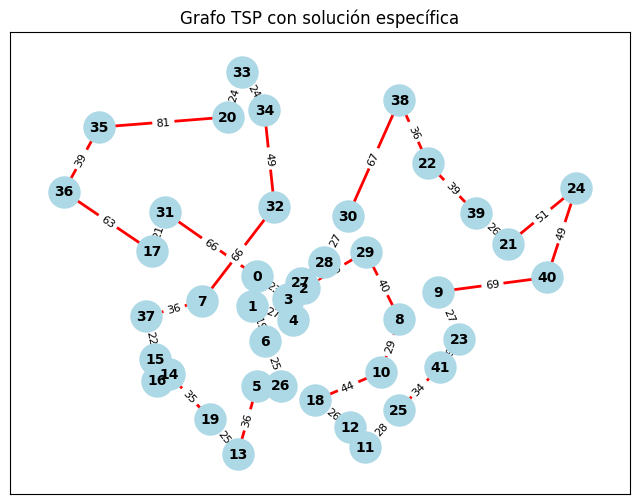

In [42]:
def algoritmo_genetico(problema=problema,tamano_poblacion=100,mutacion=0.15,elitismo=0.1,generaciones=100):
    # problema = datos del problema
    # tamano_poblacion = Tamaño de la población
    # mutacion = probabilidad de una mutación
    # elitismo = porcion de la mejor poblacion a mantener
    # generaciones = nº de generaciones a generar para finalizar

    # Genera la poblacion inicial
    nodos = list(problema.get_nodes())
    poblacion = generar_poblacion(nodos,tamano_poblacion)

    # Inicializamos valores para la mejor solucion
    mejor_solucion, mejor_distancia = evaluar_poblacion(poblacion, problema)

    # Inciamos el cliclo de generaciones
    for i in range (generaciones):
        # Cruce de la poblacion(incluye mutación)
        poblacion = cruzar(poblacion, mutacion, problema)

        #Seleccionamos la población
        poblacion = seleccionar(problema, poblacion, tamano_poblacion, elitismo)

        #Evaluamos la nueva población
        (mejor_solucion, mejor_distancia) = evaluar_poblacion(poblacion, problema)

        print("Generacion #", i, "\nLa mejor solución es:" , mejor_solucion, "\ncon distancia " , mejor_distancia, "\n")

    return mejor_solucion, mejor_distancia


tamano_poblacion = 500
mutacion = 0.4
elitismo = 0.30
generaciones = 200

mejor_solucion, mejor_distancia = algoritmo_genetico(problema,tamano_poblacion,mutacion,elitismo,generaciones)

print(f"La mejor solución encontrada es: {mejor_solucion} con {generaciones} generaciones")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)